In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)

In [2]:
df1 = pd.read_csv("../data/raw/online_retail_09_10.csv", encoding="ISO-8859-1")

In [3]:
df1.shape

(525461, 8)

In [4]:
df1.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [5]:
df1.columns

Index(['ï»¿InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ï»¿InvoiceNo  525461 non-null  str    
 1   StockCode     525461 non-null  str    
 2   Description   522533 non-null  str    
 3   Quantity      525461 non-null  int64  
 4   InvoiceDate   525461 non-null  str    
 5   UnitPrice     525461 non-null  float64
 6   CustomerID    417534 non-null  float64
 7   Country       525461 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.1 MB


In [7]:
df1.describe()

,Quantity,UnitPrice,CustomerID
count,525461.000000,525461.000000,417534.000000
mean,10.337667,4.688834,15360.645478
std,107.424110,146.126914,1680.811316
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13983.000000
50%,3.000000,2.100000,15311.000000
75%,10.000000,4.210000,16799.000000
max,19152.000000,25111.090000,18287.000000


In [8]:
df1.isnull().sum()

ï»¿InvoiceNo         0
StockCode            0
Description       2928
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      107927
Country              0
dtype: int64

In [9]:
df1.duplicated().sum()

np.int64(6865)

In [10]:
df1.nunique()

ï»¿InvoiceNo    28816
StockCode        4632
Description      4681
Quantity          825
InvoiceDate     25296
UnitPrice        1606
CustomerID       4383
Country            40
dtype: int64

In [13]:
df1["InvoiceDate"] = pd.to_datetime(df1["InvoiceDate"])
df1.dtypes

ï»¿InvoiceNo               str
StockCode                  str
Description                str
Quantity                 int64
InvoiceDate     datetime64[us]
UnitPrice              float64
CustomerID             float64
Country                    str
dtype: object

In [14]:
df1["Revenue"] = df1["Quantity"] * df1["UnitPrice"]
df1.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [15]:
df1["Revenue"].describe()

count    525461.000000
mean         18.154506
std         160.333083
min      -53594.360000
25%           3.750000
50%           9.950000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64

In [16]:
df1["Country"].value_counts().head(10)

Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64

In [17]:
df1["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3549
REGENCY CAKESTAND 3 TIER              2212
STRAWBERRY CERAMIC TRINKET BOX        1843
PACK OF 72 RETRO SPOT CAKE CASES      1466
ASSORTED COLOUR BIRD ORNAMENT         1457
60 TEATIME FAIRY CAKE CASES           1400
HOME BUILDING BLOCK WORD              1386
JUMBO BAG RED RETROSPOT               1310
LUNCH BAG RED SPOTTY                  1274
REX CASH+CARRY JUMBO SHOPPER          1232
Name: count, dtype: int64

In [18]:
country_sales = (
    df1.groupby("Country")["Revenue"]
       .sum()
       .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

In [19]:
top_products = (
    df1.groupby("Description")["Revenue"]
       .sum()
       .sort_values(ascending=False)
)

top_products.head(10)

Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64

In [20]:
monthly_sales = (
    df1.groupby(df1["InvoiceDate"].dt.to_period("M"))["Revenue"]
       .sum()
)

monthly_sales

InvoiceDate
2009-12     799847.110
2010-01     624032.892
2010-02     533091.426
2010-03     765848.761
2010-04     590580.432
2010-05     615322.830
2010-06     679786.610
2010-07     575236.360
2010-08     656776.340
2010-09     853650.431
2010-10    1045168.350
2010-11    1422654.642
2010-12     377488.450
Freq: M, Name: Revenue, dtype: float64

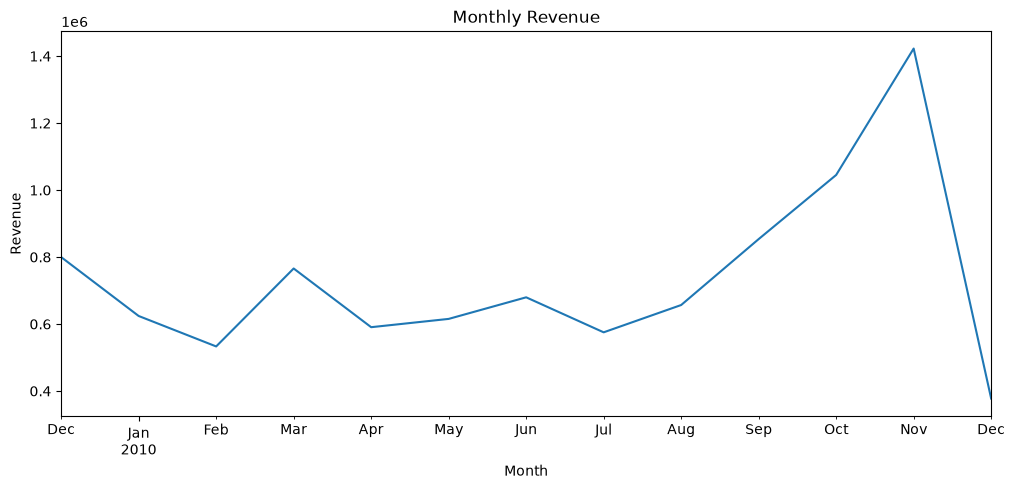

In [21]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

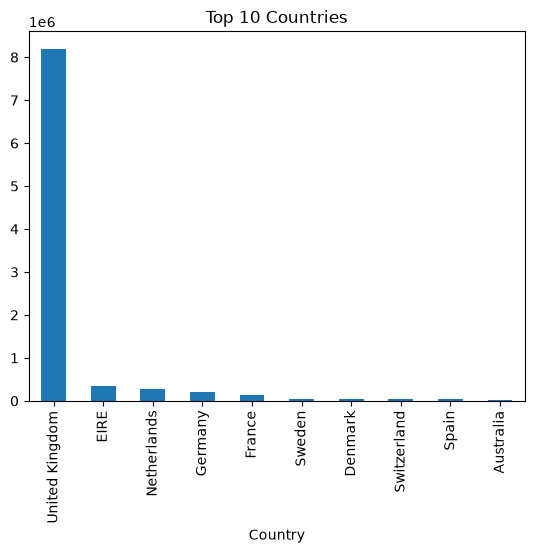

In [22]:
country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries")

plt.show()

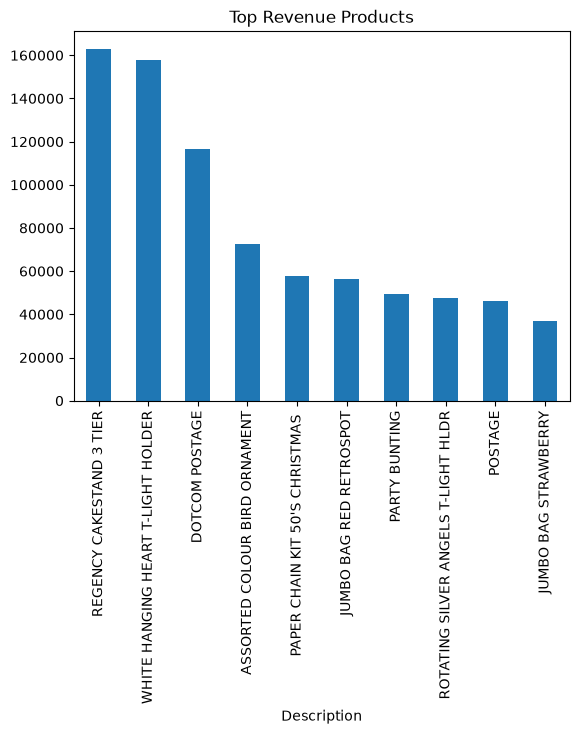

In [23]:
top_products.head(10).plot(kind="bar")

plt.title("Top Revenue Products")

plt.show()

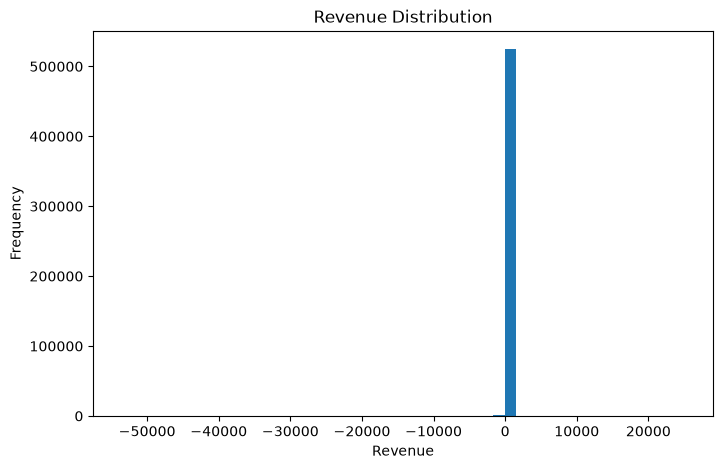

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df1["Revenue"], bins=50)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()